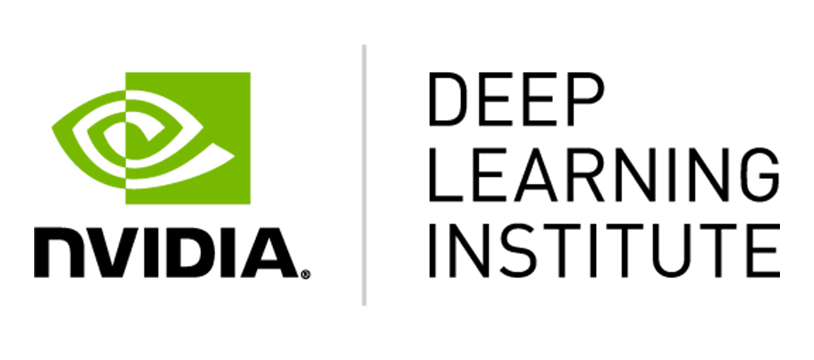

# 시퀀스 데이터

[link text](https://)이 튜토리얼에서는 이미지와 같은 독립형 데이터(시퀀스 데이터가 아닌) 요소로부터 벗어나 시퀀스의 다른 데이터 항목에 의존하는 데이터를 살펴보겠습니다. 예시를 위해 텍스트 문장을 사용하겠습니다. 기본적으로 언어는 문자가 모여 단어를 이루고 단어가 모여 문장을 이루는 형식의 시퀀스 데이터로 구성됩니다. 시퀀스 데이터의 다른 예로는 시간에 따른 주가와 날씨 데이터가 있습니다. 정지 이미지를 포함하는 영상 또한 시퀀스입니다. 데이터의 엘리먼트가 전후에 오는 내용과 관계를 지니며, 이러한 사실에는 다른 접근 방식이 필요합니다.

## 목표

* [RNN(Recurrent Neural Network)](https://developers.google.com/machine-learning/glossary#recurrent-neural-network)에 사용할 시퀀스 데이터 준비
* 단어 예측을 수행할 모델 구축 및 트레이닝

## 헤드라인 생성기

검색 창, 휴대폰 또는 텍스트 편집기 등에서 문장 자동완성을 제공하는 텍스트 예측 변수를 다들 본 적이 있을 것입니다. 우수한 텍스트 예측 변수 모델 중 다수는 매우 큰 데이터세트에 대해 트레이닝되며, 트레이닝에 많은 시간 및/또는 처리 성능이 소요됩니다. 이 연습에서는 예측 변수가 굉장히 단순하지만 그래도 언어 처리, 시퀀스 데이터, 그리고 시퀀스나 *RNN*(Recurrent Neural Network)을 트레이닝하는 데 사용되는 기존 아키텍처 엘리먼트 중 하나를 간단히 접할 수 있게 해 줍니다.

## 데이터 읽기

우리 데이터세트는 몇 개월에 걸쳐 [뉴욕 타임즈](https://www.nytimes.com/) 신문에서 발췌된 헤드라인으로 구성되어 있습니다. 먼저 기사의 모든 헤드라인을 읽어보겠습니다. 기사가 CSV 파일 형식이므로 *Pandas*를 사용하여 읽을 수 있습니다.

In [ ]:
import os
import pandas as pd

nyt_dir = 'data/nyt_dataset/articles/'

all_headlines = []
for filename in os.listdir(nyt_dir):
    if 'Articles' in filename:
        # Read in all all the data from the CSV file
        headlines_df = pd.read_csv(nyt_dir + filename)
        # Add all of the headlines to our list
        all_headlines.extend(list(headlines_df.headline.values))
len(all_headlines)

9335

첫 헤드라인 몇 개를 살펴보겠습니다.

In [ ]:
all_headlines[:20]

['N.F.L. vs. Politics Has Been Battle All Season Long',
 'Voice. Vice. Veracity.',
 'A Stand-Up’s Downward Slide',
 'New York Today: A Groundhog Has Her Day',
 'A Swimmer’s Communion With the Ocean',
 'Trail Activity',
 'Super Bowl',
 'Trump’s Mexican Shakedown',
 'Pence’s Presidential Pet',
 'Fruit of a Poison Tree',
 'The Peculiar Populism of Donald Trump',
 'Questions for: ‘On Alaska’s Coldest Days, a Village Draws Close for Warmth’',
 'The New Kids',
 'What My Chinese Mother Made',
 'Do You Think Teenagers Can Make a Difference in the World?',
 'Unknown',
 'President Pledges to Let Politics Return to Pulpits',
 'The Police Killed My Unarmed Son in 2012. I’m Still Waiting for Justice.',
 'Video of Sheep Slaughtering Ignites a Dispute',
 'This Will Change Your Mind']

## 데이터 정리

컴퓨터가 언어를 처리하는 자연어 처리(NLP) 작업의 중요한 부분은 컴퓨터가 이해할 수 있는 방식으로 텍스트를 처리하는 것입니다. 데이터세트에 나타나는 각 단어를 숫자로 표현해 보겠습니다. 이는 *토큰화*라는 프로세스에 속합니다.

이렇게 하기 전에 적절한 데이터가 있는지 확인해야 합니다. "Unknown"으로 표시된 몇 개의 헤드라인이 있습니다.  이러한 항목은 트레이닝 세트에 포함하지 않아야 하므로 필터링을 통해 제외하겠습니다.

In [ ]:
# Remove all headlines with the value of "Unknown"
all_headlines = [h for h in all_headlines if h != "Unknown"]
len(all_headlines)

8603

한 번 더 살펴보겠습니다.

In [ ]:
all_headlines[:20]

['N.F.L. vs. Politics Has Been Battle All Season Long',
 'Voice. Vice. Veracity.',
 'A Stand-Up’s Downward Slide',
 'New York Today: A Groundhog Has Her Day',
 'A Swimmer’s Communion With the Ocean',
 'Trail Activity',
 'Super Bowl',
 'Trump’s Mexican Shakedown',
 'Pence’s Presidential Pet',
 'Fruit of a Poison Tree',
 'The Peculiar Populism of Donald Trump',
 'Questions for: ‘On Alaska’s Coldest Days, a Village Draws Close for Warmth’',
 'The New Kids',
 'What My Chinese Mother Made',
 'Do You Think Teenagers Can Make a Difference in the World?',
 'President Pledges to Let Politics Return to Pulpits',
 'The Police Killed My Unarmed Son in 2012. I’m Still Waiting for Justice.',
 'Video of Sheep Slaughtering Ignites a Dispute',
 'This Will Change Your Mind',
 'Busy Start for a President, and That Was in 1933']

모델을 더 쉽게 트레이닝할 수 있도록 구두점도 제외하고 문장을 전부 소문자로 만들어야 합니다.  이러한 목적을 위해서는, "!" 또는 "?"로 끝나는 행 간, 또는 단어가 "The"처럼 대문자를 포함하는지 아니면 "the"처럼 소문자를 포함하는지 간에 별 차이가 없거나 아무 차이가 없습니다.  고유 토큰이 적을수록 모델을 더 쉽게 트레이닝할 수 있습니다.

토큰화 전에 문장을 필터링할 수는 있지만, Keras `Tokenizer`를 사용하여 이러한 작업을 전부 수행할 수 있으므로 굳이 필터링할 필요가 없습니다.

## 토큰화

지금은 데이터세트가 각각 일련의 단어로 이루어진 헤드라인 세트로 구성되어 있습니다. 우리는 모델이 이해 가능한 방식으로 이러한 단어를 표현할 수 있는 방법을 모델에 제공해야 합니다. 토큰화를 통해 텍스트의 조각을 더 작은 청크(토큰) 즉, 이 경우에는 단어로 분리합니다. 그러면 각 고유 단어에 숫자가 할당됩니다. 이런 방법을 통해 모델이 데이터를 이해할 수 있기 때문입니다. Keras에는 데이터의 토큰화를 도와주는 클래스가 있습니다.

```python
tf.keras.preprocessing.text.Tokenizer(
    num_words=None, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True,
    split=' ', char_level=False, oov_token=None, document_count=0, **kwargs
)
```

Keras에서 [토크나이저](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer) 클래스를 살펴보면 기본값이 사용 사례를 위해 미리 설정되어 있음을 확인할 수 있습니다.  `filters` 문자열은 미리 구두점을 제거하며 `lower` 플래그는 단어를 소문자로 설정합니다.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Tokenize the words in our headlines
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_headlines)
total_words = len(tokenizer.word_index) + 1
print('Total words: ', total_words)

Total words:  11753


`word_index` 사전을 훑어보면 토크나이저가 단어를 어떻게 저장하는지 확인할 수 있습니다.

In [ ]:
# Print a subset of the word_index dictionary created by Tokenizer
subset_dict = {key: value for key, value in tokenizer.word_index.items() \
               if key in ['a','man','a','plan','a','canal','panama']}
print(subset_dict)

{'a': 2, 'plan': 82, 'man': 139, 'panama': 3362, 'canal': 5487}


`texts_to_sequences` 메서드를 사용하여 토크나이저가 단어를 저장하는 방식을 확인할 수 있습니다.

In [ ]:
tokenizer.texts_to_sequences(['a','man','a','plan','a','canal','panama'])

[[2], [139], [2], [82], [2], [5487], [3362]]

## 시퀀스 생성

데이터를 토큰화했으므로 이제 각 단어를 표현 숫자로 변환하면 헤드라인에서 토큰의 시퀀스가 생성됩니다. 이러한 시퀀스를 바탕으로 딥러닝 모델을 트레이닝하게 됩니다.

예를 들면 헤드라인 "nvidia launches ray tracing gpus"를 사용해 보겠습니다. 각 단어는 해당하는 숫자(예: nvidia - 5, launches - 22, ray - 94, tracing - 16, gpus - 102)로 대체됩니다. 전체 시퀀스는 [5, 22, 94, 16, 102]가 됩니다. 하지만 헤드라인 내에서 "nvidia launches"와 같은 더 작은 시퀀스에 대해 트레이닝하는 것도 가치가 있습니다. 각 헤드라인을 사용해 시퀀스 세트를 생성하여 데이터세트를 채우겠습니다. 다음으로, 토크나이저를 사용하여 헤드라인을 시퀀스 세트로 변환하겠습니다.

In [ ]:
# Convert data to sequence of tokens
input_sequences = []
for line in all_headlines:
    # Convert our headline into a sequence of tokens
    token_list = tokenizer.texts_to_sequences([line])[0]

    # Create a series of sequences for each headline
    for i in range(1, len(token_list)):
        partial_sequence = token_list[:i+1]
        input_sequences.append(partial_sequence)

print(tokenizer.sequences_to_texts(input_sequences[:5]))
input_sequences[:5]

['n f', 'n f l', 'n f l vs', 'n f l vs politics', 'n f l vs politics has']


[[193, 125],
 [193, 125, 253],
 [193, 125, 253, 157],
 [193, 125, 253, 157, 226],
 [193, 125, 253, 157, 226, 83]]

## 시퀀스 패딩

지금은 시퀀스의 길이가 다양합니다. 모델을 데이터에 대해 트레이닝할 수 있으려면 모든 시퀀스를 같은 길이로 만들어야 합니다. 이렇게 하려면 시퀀스에 패딩을 추가합니다. Keras에 내장되어 있는 `pad_sequences` [메서드](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/sequence/pad_sequences)를 사용할 수 있습니다.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Determine max sequence length
max_sequence_len = max([len(x) for x in input_sequences])

# Pad all sequences with zeros at the beginning to make them all max length
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
input_sequences[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
       193, 125], dtype=int32)

## 예측 변수 및 타깃 생성

또한 시퀀스를 예측 변수 및 타깃으로 분할하는 것이 좋습니다. 시퀀스의 마지막 단어가 타깃이 되며 시퀀스의 첫 번째 단어가 예측 변수가 됩니다. 한 예로, 전체 헤드라인, "nvidia releases ampere graphics cards"를 살펴보겠습니다.

<table>
<tr><td>예측 변수 </td> <td>           타깃 </td></tr>
<tr><td>nvidia                   </td> <td>  releases </td></tr>
<tr><td>nvidia releases               </td> <td>  ampere </td></tr>
<tr><td>nvidia releases ampere      </td> <td>  graphics</td></tr>
<tr><td>nvidia releases ampere graphics </td> <td>  cards</td></tr>
</table>

In [ ]:
# Predictors are every word except the last
predictors = input_sequences[:,:-1]
# Labels are the last word
labels = input_sequences[:,-1]
labels[:5]

array([125, 253, 157, 226,  83], dtype=int32)

이전 섹션과 마찬가지로 이러한 타깃은 범주형입니다. 즉, 가능한 전체 어휘 중에서 한 개의 단어를 예측하는 것입니다. 네트워크가 스칼라 숫자를 예측하는 대신 바이너리 범주를 예측하도록 하는 것입니다.

In [ ]:
from tensorflow.keras import utils

labels = utils.to_categorical(labels, num_classes=total_words)

## 모델 생성

이 모델에서는 순차 데이터를 처리할 수 있도록 몇 개의 새 레이어를 사용하겠습니다.

### [임베딩 레이어](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding)

첫 번째 레이어는 임베딩 레이어입니다.

```Python
model.add(Embedding(input_dimension, output_dimension, input_length=input_len))
```

이 레이어는 토큰화된 시퀀스를 취하여 트레이닝 데이터세트의 모든 단어에 대한 임베딩을 학습합니다. 수학적으로는 임베딩이 뉴럴 네트워크의 뉴럴과 같은 방식으로 작동하지만, 개념상 임베딩의 목표는 피처의 일부나 전부의 차원 수를 줄이는 것입니다. 이 경우에는 각 단어를 벡터로 표현하며, 해당 벡터 내의 정보에 각 단어 간의 관계가 포함됩니다.

임베딩 레이어에 대한 자세한 내용은 [여기](https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/)를 참조하십시오.

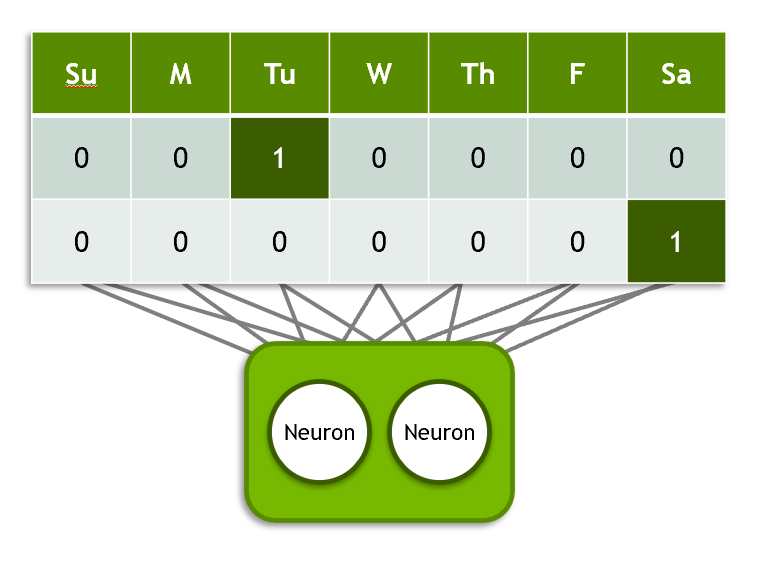

### [LSTM(Long Short Term Memory Layer)](https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM)

매우 중요한 다음 레이어는 LSTM(Long Short Term Memory Layer)입니다. LSTM은 RNN(Recurrent Neural Network)의 한 유형입니다. 지금까지 본 기존의 피드 포워드 네트워크와 달리, 순환 네트워크는 루프가 포함되어 있어 정보 지속이 가능하게 합니다. 여기에 순환 네트워크가 표현되어 있습니다.

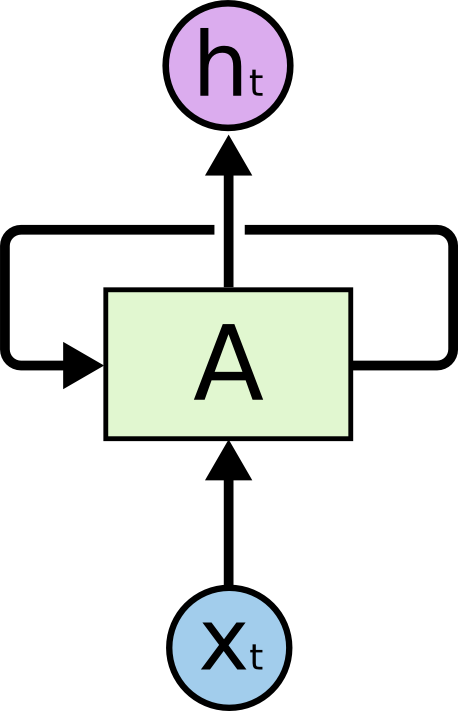

새 정보(x)가 네트워크에 전달되어 예측(h)을 반환합니다. 또한 해당 레이어의 정보가 저장되어 다음 예측을 위한 입력으로 사용됩니다. 조금 복잡하게 보일 수도 있지만 풀어서 살펴보겠습니다.

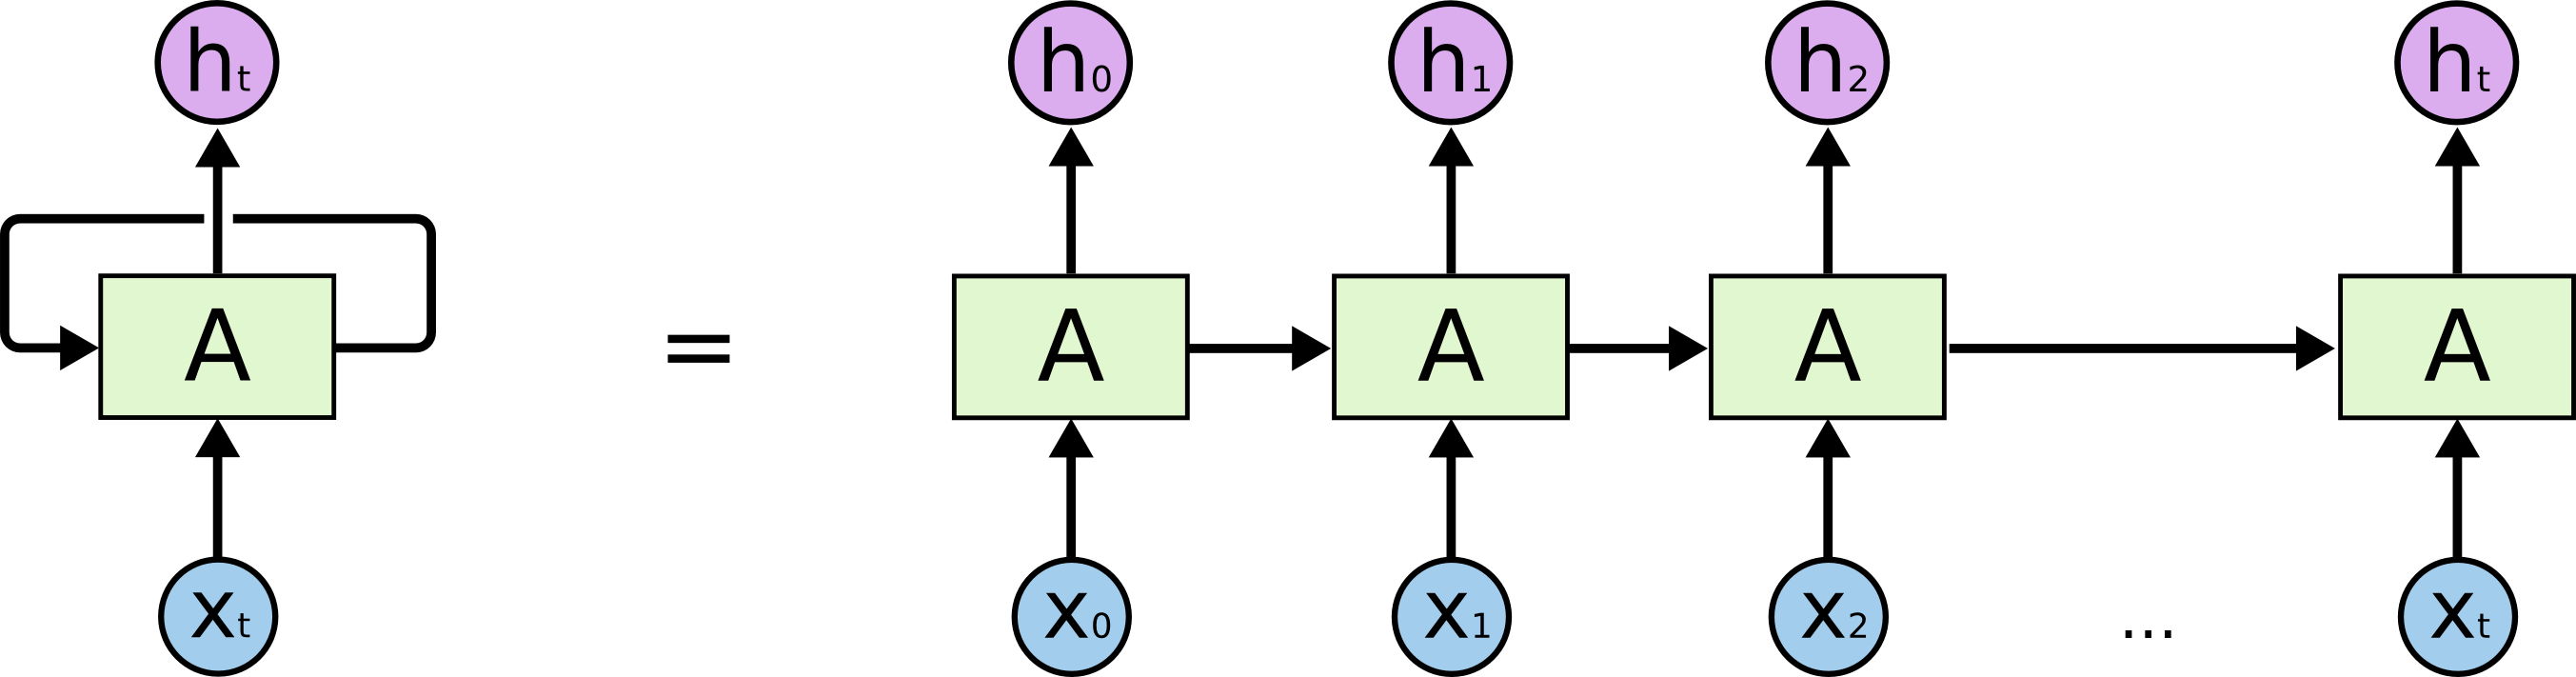

새로운 데이터 조각(x)이 네트워크에 공급되면 해당 네트워크가 예측(h)을 반환하는 동시에 다음 레이어로 일부 정보를 전달하는 것을 확인할 수 있습니다. 이 다음 레이어는 또 다른 데이터 조각을 받지만 이전 레이어로부터도 학습하게 됩니다.

기존 RNN에는 과거의 정보보다 최근 정보가 더 많이 기여하는 문제가 있습니다. LSTM은 장기적인 정보를 학습하고 유지할 수 있는 특수한 유형의 순환 레이어입니다. RNN 및 LSTM에 대한 자세한 내용을 읽어보려면 [이 문서](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)를 참조하십시오.

좋습니다. 이제 모델을 생성해 보겠습니다.

In [ ]:
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# Input is max sequence length - 1, as we've removed the last word for the label
input_len = max_sequence_len - 1

model = Sequential()

# Add input embedding layer
model.add(Embedding(total_words, 10, input_length=input_len))

# Add LSTM layer with 100 units
model.add(LSTM(100))
model.add(Dropout(0.1))

# Add output layer
model.add(Dense(total_words, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 27, 10)            117530    
_________________________________________________________________
lstm (LSTM)                  (None, 100)               44400     
_________________________________________________________________
dropout (Dropout)            (None, 100)               0         
_________________________________________________________________
dense (Dense)                (None, 11753)             1187053   
Total params: 1,348,983
Trainable params: 1,348,983
Non-trainable params: 0
_________________________________________________________________


## 모델 컴파일

앞서와 마찬가지로 범주형 크로스 엔트로피로 모델을 컴파일해야 하는 이유는 전체 어휘에서 한 단어를 범주적으로 예측하기 때문입니다. 이 경우에는 텍스트 예측이 이미지 분류와 어느 정도 동일한 정확도로 측정되지 않으므로 정확도를 지표로 사용하지 않겠습니다.

또한 LSTM 작업에 적합한 *Adam*이라는 특정 옵티마이저를 선택하겠습니다. 옵티마이저에 관한 세부적인 내용은 이 과정의 범위에서 약간 벗어나지만, 다양한 딥러닝 작업별로 서로 다른 옵티마이저가 더 효과적일 수 있다는 점을 아는 것이 중요합니다. Adam을 비롯한 여러 옵티마이저에 대한 자세한 내용은 [여기](https://medium.com/datadriveninvestor/overview-of-different-optimizers-for-neural-networks-e0ed119440c3)에서 읽어볼 수 있습니다.

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam')

## 모델 트레이닝

이전 섹션과 마찬가지로 모델을 같은 방식으로 맞춰야 합니다. 이번에는 30에포크에 대해 트레이닝할 것이며, 이 작업은 몇 분 정도 걸립니다. 보시다시피 이 경우에는 트레이닝 또는 검증 정확도 점수가 없습니다. 이는 텍스트 예측의 다른 문제를 반영합니다.

In [ ]:
model.fit(predictors, labels, epochs=30, verbose=1)

Epoch 1/30
1666/1666 [==============================] - 10s 6ms/step - loss: 7.8893
Epoch 2/30
1666/1666 [==============================] - 11s 6ms/step - loss: 7.4842
Epoch 3/30
1666/1666 [==============================] - 10s 6ms/step - loss: 7.3040
Epoch 4/30
1666/1666 [==============================] - 10s 6ms/step - loss: 7.0977
Epoch 5/30
1666/1666 [==============================] - 10s 6ms/step - loss: 6.8721
Epoch 6/30
1666/1666 [==============================] - 10s 6ms/step - loss: 6.6327
Epoch 7/30
1666/1666 [==============================] - 10s 6ms/step - loss: 6.3880
Epoch 8/30
1666/1666 [==============================] - 10s 6ms/step - loss: 6.1512
Epoch 9/30
1666/1666 [==============================] - 10s 6ms/step - loss: 5.9085
Epoch 10/30
1666/1666 [==============================] - 10s 6ms/step - loss: 5.6864
Epoch 11/30
1666/1666 [==============================] - 10s 6ms/step - loss: 5.4688
Epoch 12/30
1666/1666 [==============================] - 10s 6ms/step - lo

## 결과에 대한 논의

트레이닝이 진행되는 동안 손실이 감소했음을 알 수 있습니다. 모델을 추가적으로 트레이닝하여 손실을 줄일 수도 있지만 이렇게 하려면 시간이 좀 걸리며, 지금 당장은 완벽한 텍스트 예측 변수를 찾는 것이 목적이 아닙니다. 다음으로는 모델을 사용하여 예측을 수행해 보겠습니다.

## 예측 수행

예측을 수행하려면 시드 텍스트로 시작하고 데이터세트를 준비했던 것과 동일한 방식으로 텍스트를 준비해야 합니다. 즉, 토큰화와 패딩을 수행해야 합니다. 토큰화와 패딩이 완료되면 모델에 전달하여 예측을 수행할 수 있습니다. 이를 수행하기 위해 `predict_next_token`이라는 함수를 생성합니다.

In [ ]:
def predict_next_token(seed_text):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    prediction = model.predict_classes(token_list, verbose=0)
    return prediction

In [ ]:
prediction = predict_next_token("today in new york")
prediction

Instructions for updating:
Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).


array([9])

토크나이저를 사용하여 예측된 단어를 디코딩하겠습니다.

In [ ]:
tokenizer.sequences_to_texts([prediction])

['is']

## 새 헤드라인 생성

새 단어를 예측할 수 있게 되었으니 이제 단어 2개 이상으로 된 헤드라인을 예측할 수 있는 함수를 만들어 보겠습니다. 아래 함수는 임의의 길이의 새 헤드라인을 생성합니다.

In [ ]:
def generate_headline(seed_text, next_words=1):
    for _ in range(next_words):
        # Predict next token
        prediction = predict_next_token(seed_text)
        # Convert token to word
        next_word = tokenizer.sequences_to_texts([prediction])[0]
        # Add next word to the headline. This headline will be used in the next pass of the loop.
        seed_text += " " + next_word
    # Return headline as title-case
    return seed_text.title()

이제 몇 개의 헤드라인을 시도해보십시오!

In [ ]:
seed_texts = [
    'washington dc is',
    'today in new york',
    'the school district has',
    'crime has become']
for seed in seed_texts:
    print(generate_headline(seed, next_words=5))

Washington Dc Is Freedom On A Lens In
Today In New York Is An Monet Feel A
The School District Has The Rise In The Trump
Crime Has Become The Way To Give Up


30에포크의 트레이닝 후에는 결과가 약간 실망스러울 수도 있습니다.  보시다시피 대부분의 헤드라인이 문법적으로는 어느 정도 이해가 되지만 맥락적으로도 잘 이해가 되는 것은 아닙니다.  더 많은 에포크로 트레이닝하면 결과가 어느 정도 개선될 수도 있습니다. 트레이닝 `fit` 셀을 반복적으로 실행하여 매번 30에포크씩 더 트레이닝하면 됩니다.  그러면 손실 값이 감소하는 모습을 확인할 수 있습니다.  그런 다음 다시 테스트해 보십시오.  결과가 크게 달라질 수 있습니다!

Keras 임베딩 레이어에서 그랬던 것처럼 트레이닝 도중에 학습하는 대신 사전 트레이닝된 임베딩을 Word2Vec 또는 GloVe와 함께 사용해 보는 것도 개선 방법이 될 수 있습니다.  이를 수행하는 방법에 대한 정보는 [여기](https://blog.keras.io/using-pre-trained-word-embeddings-in-a-keras-model.html)에서 확인할 수 있습니다.

하지만 궁극적으로는 NLP가 단순한 LSTM 모델을 넘어 트랜스포머 기반의 사전 트레이닝된 모델로 넘어갔으며, 이러한 모델은 Wikipedia와 같은 방대한 양의 텍스트 데이터로부터 언어 맥락을 학습할 수 있습니다.  그런 다음 이런 사전 트레이닝된 모델이 전이 학습의 시작점으로 사용되어 텍스트 완성과 관련하여 방금 시도한 것과 같은 NLP 작업을 해결할 수 있습니다.  이러한 모델 중 하나를 직접 사용해 보려면 [GPT-2 모델](https://openai.com/blog/better-language-models/)을 기반으로 한 [여기의 첨단 텍스트 예측 변수](https://transformer.huggingface.co/doc/gpt2-large)를 확인해 보십시오.

트랜스포머 기반 모델에 대해 자세히 알아보려면 BERT(Bidirectional Encoder Representations from Transformers)에 관한 [이 블로그](https://ai.googleblog.com/2018/11/open-sourcing-bert-state-of-art-pre.html)를 살펴보고 이 DLI 과정의 "다음 단계" 페이지에서 추가 수업 활동에 대한 정보를 찾아보십시오.

## 요약

잘하셨습니다! 헤드라인의 단어를 예측하기 위한 모델을 성공적으로 트레이닝했으며 해당 모델을 사용하여 다양한 길이의 헤드라인을 생성했습니다. 자유롭게 헤드라인 몇 개를 더 실험하고 생성해 보시기 바랍니다.

### 메모리 지우기
넘어가기 전에 다음 셀을 실행하여 GPU 메모리를 지워주시기 바랍니다.

In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

## 다음

축하합니다. 이 과정의 모든 학습 목표를 완료했습니다!

마지막 연습으로, 그리고 과정 내 인증서 획득을 위해 [평가](07_assessment.ipynb)에서 종합적인 이미지 분류 문제를 완료하시기 바랍니다.